<a href="https://colab.research.google.com/github/Ravi-ranjan1801/Data-Warehousing-Mining-Lab/blob/main/DWM_Lab_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lab - 06**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

In [2]:
url = "https://sci2s.ugr.es/keel/dataset.php?cod=18"

print("KEEL Iris dataset:")
print(url)

KEEL Iris dataset:
https://sci2s.ugr.es/keel/dataset.php?cod=18


In [3]:
from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=[
        'SepalLength',
        'SepalWidth',
        'PetalLength',
        'PetalWidth'
    ]
)

df['Class'] = [
    'Iris-setosa' if x == 0
    else 'Iris-versicolor' if x == 1
    else 'Iris-virginica'
    for x in iris.target
]

df.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
print("Shape of dataset:", df.shape)

display(df.head(10))

Shape of dataset: (150, 5)


,SepalLength,SepalWidth,PetalLength,PetalWidth,Class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [5]:
print("Class Distribution:")
print(df['Class'].value_counts())

Class Distribution:
Class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


### **1. Entropy**

In [6]:
def entropy(series):
    probabilities = series.value_counts(normalize=True)

    return -sum(
        p * np.log2(p)
        for p in probabilities
        if p > 0
    )

In [7]:
class_entropy = entropy(df['Class'])

print("Entropy of Class =", round(class_entropy, 4))

Entropy of Class = 1.585


In [8]:
features = [
    'SepalLength',
    'SepalWidth',
    'PetalLength',
    'PetalWidth'
]

df_discrete = df.copy()

for feature in features:
    df_discrete[feature] = pd.qcut(
        df[feature],
        q=3,
        labels=['Low', 'Medium', 'High'],
        duplicates='drop'
    )

display(df_discrete.head())

,SepalLength,SepalWidth,PetalLength,PetalWidth,Class
0,Low,High,Low,Low,Iris-setosa
1,Low,Medium,Low,Low,Iris-setosa
2,Low,Medium,Low,Low,Iris-setosa
3,Low,Medium,Low,Low,Iris-setosa
4,Low,High,Low,Low,Iris-setosa


In [9]:
for feature in features:
    print("\n", feature)
    print(df_discrete[feature].value_counts())


 SepalLength
SepalLength
Medium    56
Low       52
High      42
Name: count, dtype: int64

 SepalWidth
SepalWidth
Low       57
Medium    50
High      43
Name: count, dtype: int64

 PetalLength
PetalLength
Medium    54
Low       50
High      46
Name: count, dtype: int64

 PetalWidth
PetalWidth
Medium    52
Low       50
High      48
Name: count, dtype: int64


In [10]:
print("Entropy of each feature:\n")

for feature in features:
    h = entropy(df_discrete[feature])
    print(feature, "=", round(h, 4))

Entropy of each feature:

SepalLength = 1.5747
SepalWidth = 1.5755
PetalLength = 1.5819
PetalWidth = 1.5842


### **2. Joint Entropy**

In [11]:
def joint_entropy(x, y):
    joint_prob = pd.crosstab(
        x,
        y,
        normalize=True
    )

    probabilities = joint_prob.values.flatten()

    return -sum(
        p * np.log2(p)
        for p in probabilities
        if p > 0
    )

In [12]:
print("Joint Entropy with Class:\n")

for feature in features:
    hxy = joint_entropy(
        df_discrete[feature],
        df_discrete['Class']
    )

    print(
        f"H({feature}, Class) = {hxy:.4f}"
    )

Joint Entropy with Class:

H(SepalLength, Class) = 2.5128
H(SepalWidth, Class) = 2.8033
H(PetalLength, Class) = 1.8422
H(PetalWidth, Class) = 1.7998


### **3. Conditional Entropy**

In [13]:
def conditional_entropy(y, x):
    total = len(y)
    result = 0

    for value in x.unique():

        subset_y = y[x == value]

        probability_x = len(subset_y) / total

        result += probability_x * entropy(subset_y)

    return result

In [14]:
print("Conditional Entropy:\n")

for feature in features:

    h = conditional_entropy(
        df_discrete['Class'],
        df_discrete[feature]
    )

    print(
        f"H(Class | {feature}) = {h:.4f}"
    )

Conditional Entropy:

H(Class | SepalLength) = 0.9380
H(Class | SepalWidth) = 1.2278
H(Class | PetalLength) = 0.2603
H(Class | PetalWidth) = 0.2156


### **4. Information Gain**

In [15]:
def information_gain(y, x):
    return entropy(y) - conditional_entropy(y, x)

In [16]:
print("Information Gain:\n")

information_gain_results = {}

for feature in features:

    ig = information_gain(
        df_discrete['Class'],
        df_discrete[feature]
    )

    information_gain_results[feature] = ig

    print(
        f"IG(Class, {feature}) = {ig:.4f}"
    )

Information Gain:

IG(Class, SepalLength) = 0.6470
IG(Class, SepalWidth) = 0.3571
IG(Class, PetalLength) = 1.3247
IG(Class, PetalWidth) = 1.3694


### **5. Mutual Information**

In [17]:
def mutual_information(x, y):
    return (
        entropy(x)
        + entropy(y)
        - joint_entropy(x, y)
    )

In [18]:
print("Mutual Information:\n")

mi_results = {}

for feature in features:

    mi = mutual_information(
        df_discrete[feature],
        df_discrete['Class']
    )

    mi_results[feature] = mi

    print(
        f"MI({feature}, Class) = {mi:.4f}"
    )

Mutual Information:

MI(SepalLength, Class) = 0.6470
MI(SepalWidth, Class) = 0.3571
MI(PetalLength, Class) = 1.3247
MI(PetalWidth, Class) = 1.3694


### **6. Gini Index**

In [19]:
def gini_index(series):

    probabilities = series.value_counts(
        normalize=True
    )

    return 1 - sum(
        p ** 2
        for p in probabilities
    )

In [20]:
gini = gini_index(df['Class'])

print("GINI Index of Class =", round(gini, 4))

GINI Index of Class = 0.6667


In [21]:
def weighted_gini(y, x):

    total = len(y)
    result = 0

    for value in x.unique():

        subset = y[x == value]

        weight = len(subset) / total

        result += weight * gini_index(subset)

    return result

In [22]:
print("Weighted GINI after splitting:\n")

gini_results = {}

for feature in features:

    gini = weighted_gini(
        df_discrete['Class'],
        df_discrete[feature]
    )

    gini_results[feature] = gini

    print(
        f"GINI({feature}) = {gini:.4f}"
    )

Weighted GINI after splitting:

GINI(SepalLength) = 0.3927
GINI(SepalWidth) = 0.5184
GINI(PetalLength) = 0.0966
GINI(PetalWidth) = 0.0748


In [23]:
results = []

for feature in features:

    h_feature = entropy(
        df_discrete[feature]
    )

    h_class = entropy(
        df_discrete['Class']
    )

    h_joint = joint_entropy(
        df_discrete[feature],
        df_discrete['Class']
    )

    h_conditional = conditional_entropy(
        df_discrete['Class'],
        df_discrete[feature]
    )

    ig = information_gain(
        df_discrete['Class'],
        df_discrete[feature]
    )

    mi = mutual_information(
        df_discrete[feature],
        df_discrete['Class']
    )

    gini = weighted_gini(
        df_discrete['Class'],
        df_discrete[feature]
    )

    results.append([
        feature,
        h_feature,
        h_joint,
        h_conditional,
        ig,
        mi,
        gini
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        'Feature',
        'Entropy',
        'Joint Entropy',
        'Conditional Entropy',
        'Information Gain',
        'Mutual Information',
        'GINI Index'
    ]
)

results_df.round(4)

,Feature,Entropy,Joint Entropy,Conditional Entropy,Information Gain,Mutual Information,GINI Index
0,SepalLength,1.5747,2.5128,0.9380,0.6470,0.6470,0.3927
1,SepalWidth,1.5755,2.8033,1.2278,0.3571,0.3571,0.5184
2,PetalLength,1.5819,1.8422,0.2603,1.3247,1.3247,0.0966
3,PetalWidth,1.5842,1.7998,0.2156,1.3694,1.3694,0.0748


In [24]:
best_ig = results_df.loc[
    results_df['Information Gain'].idxmax()
]

best_mi = results_df.loc[
    results_df['Mutual Information'].idxmax()
]

print("Best feature according to Information Gain:")
print(best_ig['Feature'])

print("\nBest feature according to Mutual Information:")
print(best_mi['Feature'])

Best feature according to Information Gain:
PetalWidth

Best feature according to Mutual Information:
PetalWidth


In [25]:
best_gini = results_df.loc[
    results_df['GINI Index'].idxmin()
]

print(
    "Best feature according to GINI:",
    best_gini['Feature']
)

Best feature according to GINI: PetalWidth


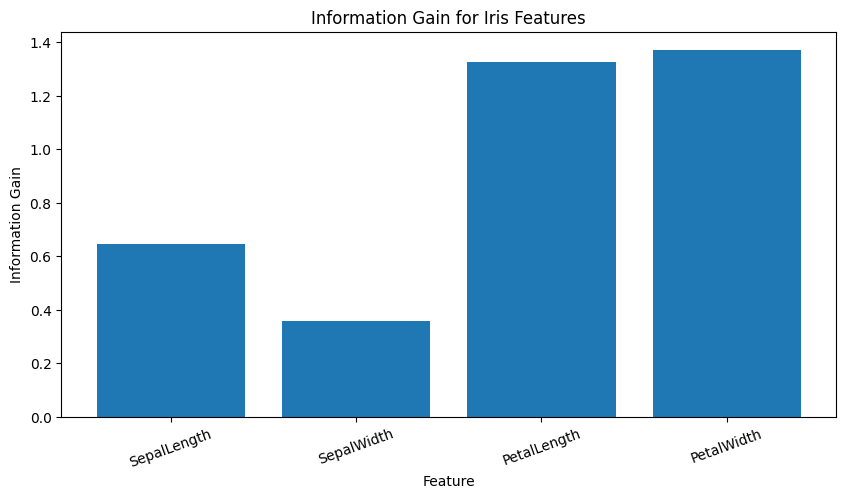

In [26]:
plt.figure(figsize=(10, 5))

plt.bar(
    results_df['Feature'],
    results_df['Information Gain']
)

plt.xlabel('Feature')
plt.ylabel('Information Gain')
plt.title('Information Gain for Iris Features')

plt.xticks(rotation=20)
plt.show()

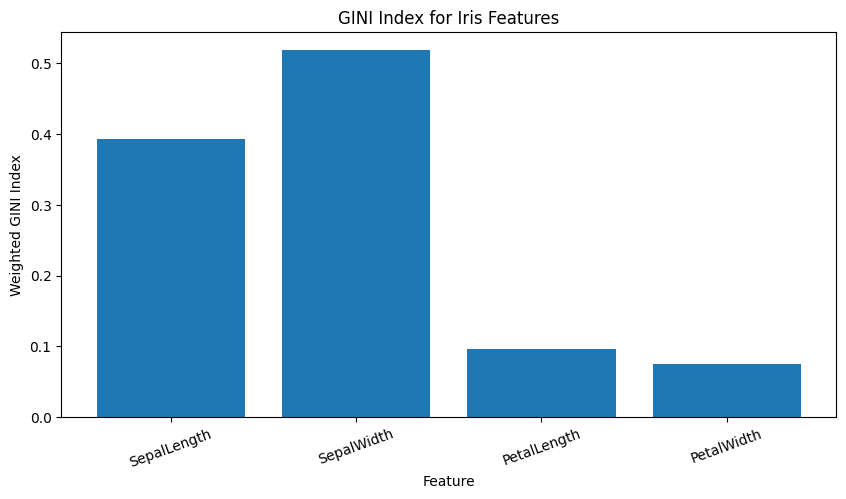

In [27]:
plt.figure(figsize=(10, 5))

plt.bar(
    results_df['Feature'],
    results_df['GINI Index']
)

plt.xlabel('Feature')
plt.ylabel('Weighted GINI Index')
plt.title('GINI Index for Iris Features')

plt.xticks(rotation=20)
plt.show()

## **Concepts Used**
**1. Entropy**

Measures uncertainty/impurity.

$$ H(X)=-\sum p(x)\log_2p(x) $$

Higher entropy → more uncertainty.

**2. Joint Entropy**

Measures the uncertainty in two variables together.

$$ H(X,Y) $$
**3. Conditional Entropy**

Measures the remaining uncertainty in Y after knowing X.

$$ H(Y|X) $$
**4. Information Gain**

Measures how much knowing a feature reduces uncertainty about the target.

$$ IG(Y,X)=H(Y)-H(Y|X) $$

Higher IG = better feature.

**5. Mutual Information**

Measures the amount of information shared between two variables.

$$ I(X;Y)=H(X)+H(Y)-H(X,Y) $$

For this feature-vs-class setup:

$$ \boxed{MI(X,Y)=IG(Y,X)} $$
**6. GINI Index**

Measures impurity:

$$ Gini=1-\sum p_i^2 $$

Lower GINI = purer split.